In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Cell 1 - Configuration and standardized dataset loading

import pandas as pd
from src.data.dataset import format_dataset
from src.config import default_config, config_hash
from src.io.artifacts import save_json, save_parquet

# User loads raw inputs themselves
returns_input = pd.read_csv(
    "data/input/230216_returns.csv",
    index_col=0,
    parse_dates=True,
)
dictionary = pd.read_excel(
    "data/input/230210 Factor Set - Dictionnary (bbg only).xlsx",
)

# Build configuration
config = default_config()
config["targets"] = ["SPX Index"]

# Build the standardized returns DataFrame with price/rate split, inf and clipping handled
returns_df, price_tickers, rate_tickers = format_dataset(
    returns=returns_input,
    dictionary=dictionary,
    clip_abs_max=config["clip_abs_max"],
)

run_id = f"sri_{config_hash(config)}"
print(f"run_id: {run_id}")
print(f"returns_df shape: {returns_df.shape}")
print(f"price tickers: {len(price_tickers)}, rate tickers: {len(rate_tickers)}")

# Persist standardized inputs
save_parquet(returns_df, f"{config['artifacts_root']}/{run_id}/returns.parquet")
save_json(config, f"{config['artifacts_root']}/{run_id}/config.json")
save_json(
    {"price_tickers": price_tickers, "rate_tickers": rate_tickers},
    f"{config['artifacts_root']}/{run_id}/ticker_split.json",
)

/home/onyxia/work/src/data/dataset.py:72: UserWarning: 69 dictionary ticker(s) not present in data: ['BJAMA Index', 'COSMIND Index', 'COSMSERV Index', 'DGB20YY Index', 'DWAP Index'] ...
  price_tickers, rate_tickers = load_transform(


run_id: sri_54bf4c8d65
returns_df shape: (6002, 1066)
price tickers: 996, rate tickers: 70


In [3]:
# Cell 1 bis - Identify price tickers with returns <= -1 (cause of log1p warning)

bad_price = []
for col in price_tickers:
    if col in returns_df.columns:
        s = returns_df[col]
        n_extreme = (s <= -0.99).sum()
        if n_extreme > 0:
            bad_price.append((col, n_extreme, float(s.min())))
bad_price.sort(key=lambda x: x[2])
print(f"Found {len(bad_price)} price tickers with returns <= -0.99")
for t, n, mn in bad_price[:20]:
    print(f"  {t}: {n} obs at extreme, min = {mn:.4f}")

Found 1 price tickers with returns <= -0.99
  CL1 Comdty: 1 obs at extreme, min = -3.0597


In [4]:
# Cell 2 - Rolling features at daily frequency

from src.features.rolling import build_rolling_features

features_daily = build_rolling_features(
    returns_df,
    price_tickers=price_tickers,
    rate_tickers=rate_tickers,
    window=config["rolling_window_days"],
    min_periods=config["rolling_min_periods"],
)
print(f"features_daily: {features_daily.shape}")
save_parquet(features_daily, f"{config['artifacts_root']}/{run_id}/features_daily.parquet")

/home/onyxia/work/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


features_daily: (6002, 1066)


In [5]:
# Cell 3 - Rebalancing schedule (Business Month End)

rebalancing_dates = pd.date_range(
    start=features_daily.index[0],
    end=features_daily.index[-1],
    freq="BME",
)
print(f"rebalancing_dates: {len(rebalancing_dates)} dates from {rebalancing_dates[0].date()} to {rebalancing_dates[-1].date()}")

rebalancing_dates: 276 dates from 2000-01-31 to 2022-12-30


In [6]:
# Cell 4 - Build and align X and Y daily datasets with lag

from src.features.alignment import XYSpec, build_XY, align_XY

spec = XYSpec(targets=config["targets"], features=config["features"])  # all non-targets used as features
Y_daily, X_daily = build_XY(features_daily, spec)
X_lagged = X_daily.shift(config["lag_days"])
Y_aligned, X_aligned = align_XY(Y_daily, X_lagged)

print(f"Y_aligned: {Y_aligned.shape}, X_aligned: {X_aligned.shape}")
save_parquet(Y_aligned, f"{config['artifacts_root']}/{run_id}/Y_aligned.parquet")
save_parquet(X_aligned, f"{config['artifacts_root']}/{run_id}/X_aligned.parquet")

Y_aligned: (5964, 1), X_aligned: (5964, 1065)


In [7]:
# Prep for Cell 5 - Clear caches and joblib pools

import shutil
from pathlib import Path
from joblib.externals.loky import get_reusable_executor

# 1. Remove bytecode caches that might mask the patched .py
for cache_dir in Path(".").rglob("__pycache__"):
    if "external" in str(cache_dir) or "lnlm" in str(cache_dir).lower():
        shutil.rmtree(cache_dir, ignore_errors=True)
        print(f"Cleared: {cache_dir}")

# 2. Terminate all persistent joblib pools to force fresh workers
get_reusable_executor().shutdown(wait=True)
print("Joblib pool shut down, next Parallel call will spawn fresh workers")

# Cell 5 - LNLM panel estimation

from src.models.estimation_panel import fit_lnlm_panel

# Smoke test only: subset features and rebalancing dates
# X_smoke = X_aligned.iloc[:, :20]
# rebalancing_dates_smoke = rebalancing_dates[::12]  # yearly cadence

# Smoke variant: N random features for sanity check before full grid
# import numpy as np
# N_FEATURES_SMOKE = 200
# rng_smoke = np.random.default_rng(42)
# sample_idx = rng_smoke.choice(X_aligned.shape[1], size=N_FEATURES_SMOKE, replace=False)
# X_smoke = X_aligned.iloc[:, sample_idx]
# print(f"Smoke: {X_smoke.shape[1]} random features sampled with seed 42")

rmse_long, params_long = fit_lnlm_panel(
    Y=Y_aligned,
    X=X_aligned, # smoke: x_smoke, else X_aligned
    rebalancing_dates=rebalancing_dates, # smoke: rebalancing_dates_smoke, else rebalancing_dates
    config=config,
)
print(f"rmse_long: {len(rmse_long)} fits over {rmse_long['date'].nunique()} dates and {rmse_long['feature'].nunique()} features")
save_parquet(rmse_long, f"{config['artifacts_root']}/{run_id}/rmse_long.parquet")
save_parquet(params_long, f"{config['artifacts_root']}/{run_id}/params_long.parquet")

Cleared: external/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_extra/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_compat/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/_packaging/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_compat/numpy/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_compat/common/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_extra/_lib/__pycache__
Cleared: .venv/lib/python3.13/site-packages/sklearn/externals/array_api_extra/_lib/_utils/__pycache__
Cleared: .venv/lib/python3.13/site-packages/joblib/externals/__pycache__
Cleared: .venv/lib/python3.13/site-packages/joblib/externals/cloudpickle/__pycache__
Cleared: .venv/lib/python3.13/site-packages/joblib/externals/loky/__pycache__
Cl

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 102 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 228 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 390 tasks      | elapsed: 11.6min
[Parallel(n_jobs=-1)]: Done 588 tasks      | elapsed: 16.5min
[Parallel(n_jobs=-1)]: Done 822 tasks      | elapsed: 23.4min
[Parallel(n_jobs=-1)]: Done 1065 out of 1065 | elapsed: 30.4min finished


rmse_long: 224598 fits over 263 dates and 997 features


In [8]:
# Cell 6 - Build P_t (current RMSE distribution per target and date)

from src.distributions.kde import build_global_grid_from_rmse, build_Pt_distributions
from src.io.artifacts import save_npy

grid = build_global_grid_from_rmse(rmse_long, grid_size=config["kde_grid_size"])
Pt = build_Pt_distributions(
    rmse_long=rmse_long,
    grid=grid,
    bandwidth=config["kde_bandwidth"],
    keep_top_quantile=config["keep_top_quantile"],   # smoke: 1.0 to keep all RMSE values, else config["keep_top_quantile"]
    min_samples=config["min_samples"],   # smoke: 2 to relaxed threshold, else config["min_samples"]
)
print(f"Pt: {Pt.shape}, levels: {Pt.index.names}")
save_npy(grid, f"{config['artifacts_root']}/{run_id}/grid.npy")
save_parquet(Pt, f"{config['artifacts_root']}/{run_id}/Pt.parquet")

Pt: (263, 400), levels: ['date', 'target']


In [9]:
# Cell 7 - Memory distributions Q_t (pre-crisis) and R_t (normal-times)

from src.distributions.memory import build_memory_distributions, forward_cumulative_return

Qt_dict, Rt_dict = {}, {}
for tgt in config["targets"]:
    Pt_tgt = Pt.xs(tgt, level="target", drop_level=False)
    valid_dates = Pt_tgt.index.get_level_values("date").unique()
    Y_at_rebal = Y_aligned.loc[Y_aligned.index.intersection(valid_dates), tgt]
    fwd = forward_cumulative_return(Y_at_rebal, horizon=config["forward_months"])
    Qt, Rt = build_memory_distributions(
        Pt=Pt_tgt,
        grid=grid,
        target_forward_return=fwd,
        forward=config["forward_months"],
        halflife_years=config["memory_halflife_years"],
    )
    Qt_dict[tgt] = Qt
    Rt_dict[tgt] = Rt
    save_parquet(Qt, f"{config['artifacts_root']}/{run_id}/Qt_{tgt.replace(' ', '_')}.parquet")
    save_parquet(Rt, f"{config['artifacts_root']}/{run_id}/Rt_{tgt.replace(' ', '_')}.parquet")
print(f"Qt[{config['targets'][0]}]: {Qt_dict[config['targets'][0]].shape}")

Qt[SPX Index]: (263, 400)


In [10]:
# Cell 8 - Hellinger distances and SRI signal

from src.distributions.hellinger import compute_hellinger_series
from src.signals.sri import sri_from_hellinger, sri_from_state_comparison

H_PQ_dict, H_PR_dict, sri_dict = {}, {}, {}
for tgt in config["targets"]:
    Pt_tgt = Pt.xs(tgt, level="target")
    H_PQ = compute_hellinger_series(Pt_tgt, Qt_dict[tgt], grid)
    H_PR = compute_hellinger_series(Pt_tgt, Rt_dict[tgt], grid)
    H_PQ_dict[tgt] = H_PQ
    H_PR_dict[tgt] = H_PR
    sri_dict[tgt] = sri_from_hellinger(H_PQ)
    # SRI : sri_from_hellinger(H_PQ) or sri_from_state_comparison(H_PQ, H_PR)

H_PQ_df = pd.DataFrame(H_PQ_dict)
H_PR_df = pd.DataFrame(H_PR_dict)
sri_df = pd.DataFrame(sri_dict)
print(f"sri_df: {sri_df.shape}, mean SRI by target:\n{sri_df.mean()}")
print(f"H_PQ stats: mean={H_PQ_df.mean().values[0]:.4f}, H_PR stats: mean={H_PR_df.mean().values[0]:.4f}")
save_parquet(H_PQ_df, f"{config['artifacts_root']}/{run_id}/hellinger_pq.parquet")
save_parquet(H_PR_df, f"{config['artifacts_root']}/{run_id}/hellinger_pr.parquet")
save_parquet(sri_df, f"{config['artifacts_root']}/{run_id}/sri.parquet")

sri_df: (263, 1), mean SRI by target:
SPX Index    0.414449
dtype: float64
H_PQ stats: mean=0.7543, H_PR stats: mean=0.7334


In [11]:
# Cell 9 - Monthly backtest

from src.backtest.monthly import run_monthly_backtest

result = run_monthly_backtest(
    daily_returns=returns_df,
    sri_df=sri_df,
    targets=config["targets"],
    leverage_risk_on=config["leverage_risk_on"],
    leverage_risk_off=config["leverage_risk_off"],
)

for key in ["daily_leverage", "strategy_daily_returns", "equity_curves", "buyhold_equity_curves", "monthly_positions"]:
    save_parquet(result[key], f"{config['artifacts_root']}/{run_id}/{key}.parquet")
print(f"Equity curves: {result['equity_curves'].shape}")
print(f"Final equity:\n{result['equity_curves'].iloc[-1]}")

Equity curves: (6002, 1)
Final equity:
SPX Index    3.065667
Name: 2023-01-04 00:00:00, dtype: float64


In [12]:
# Cell 10 - Performance metrics

from src.backtest.metrics import perf_metrics_multi_target
import json

metrics = perf_metrics_multi_target(
    strategy_daily_returns=result["strategy_daily_returns"],
    equity_curves=result["equity_curves"],
)
print(json.dumps(metrics, indent=2))
save_json(metrics, f"{config['results_root']}/{run_id}/metrics.json")

{
  "SPX Index": {
    "annualized_return": 0.09186623183311271,
    "annualized_volatility": 0.28507740486874733,
    "sharpe": 0.30835028627719374,
    "cagr": 0.051696090274856,
    "max_drawdown": -0.7126472644605156,
    "calmar": 0.07254092291224985,
    "final_equity": 3.06566743526453
  }
}


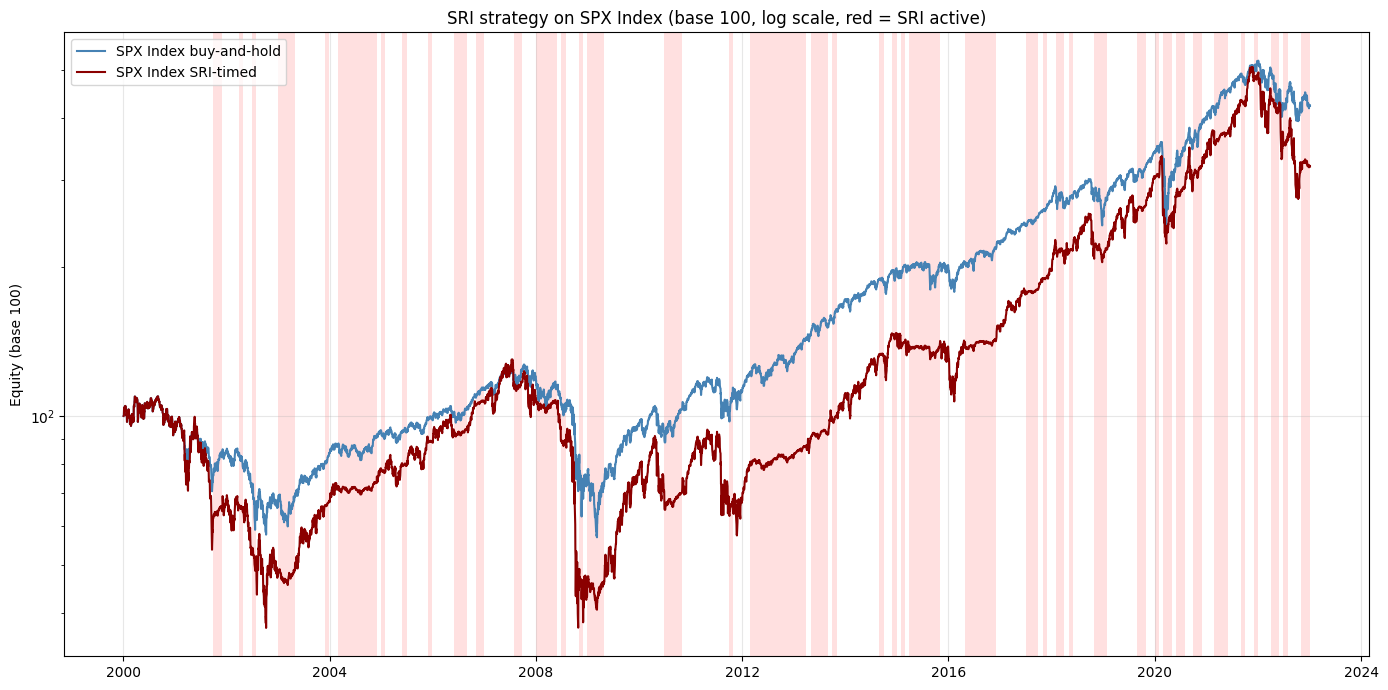

In [13]:
# Cell 11 - Plot equity curves with SRI shading

import matplotlib.pyplot as plt
import os

target = config["targets"][0]

eq_market = result["buyhold_equity_curves"][target].dropna()
eq_strategy = result["equity_curves"][target].dropna()
common_idx = eq_market.index.intersection(eq_strategy.index)
eq_market = 100 * eq_market.loc[common_idx] / eq_market.loc[common_idx].iloc[0]
eq_strategy = 100 * eq_strategy.loc[common_idx] / eq_strategy.loc[common_idx].iloc[0]

sri_daily = sri_df[target].reindex(common_idx, method='ffill').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(eq_market.index, eq_market.values, label=f'{target} buy-and-hold',
        linewidth=1.5, color='steelblue')
ax.plot(eq_strategy.index, eq_strategy.values, label=f'{target} SRI-timed',
        linewidth=1.5, color='darkred')

# Shade SRI=1 (risk-off signal emitted)
active = (sri_daily == 1).values
dates = sri_daily.index
in_block, block_start = False, None
for i in range(len(dates)):
    if active[i] and not in_block:
        block_start, in_block = dates[i], True
    elif not active[i] and in_block:
        ax.axvspan(block_start, dates[i], alpha=0.12, color='red', linewidth=0)
        in_block = False
if in_block:
    ax.axvspan(block_start, dates[-1], alpha=0.12, color='red', linewidth=0)

ax.set_title(f'SRI strategy on {target} (base 100, log scale, red = SRI active)')
ax.set_ylabel('Equity (base 100)')
ax.set_yscale('log')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs(f"{config['results_root']}/{run_id}", exist_ok=True)
plt.savefig(f"{config['results_root']}/{run_id}/sri_chart_{target.replace(' ', '_')}.png",
            dpi=150, bbox_inches='tight')
plt.show()